# Evaluate — DF-FusionModel CAN v6 (Dual-Modality: Spatial + rPPG)

## 📋 Hướng dẫn Input Kaggle

| Dataset | Nội dung | Biến đường dẫn |
| :--- | :--- | :--- |
| `thinhphan272/ffpp-c23-face-cache` | Ảnh frame spatial đã crop | `CACHE_DIR_SPATIAL` |
| `thinhphan272/ffpp-c23-rppg-cache` | Tín hiệu rPPG đã trích | `CACHE_DIR_RPPG` |
| Dataset chứa `fusion_model_best.pth` | Checkpoint + `train_history.csv` | `BEST_PATH`, `TRAIN_HISTORY_CSV` |

> **Notebook evaluate-only** — cần add **cả 2 dataset dữ liệu** spatial + rPPG, cùng checkpoint fusion.


## 1. Cấu hình

In [1]:
import os, glob, time, random, copy, json, math
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import timm
import warnings
warnings.filterwarnings("ignore")

# ==================== SỬA CÁC ĐƯỜNG DẪN NÀY ====================
CACHE_DIR_SPATIAL  = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"
CACHE_DIR_RPPG     = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"
SPATIAL_OLD_PREFIX = "/kaggle/working/ffpp_c23_cache"
RPPG_OLD_PREFIX    = "/kaggle/working/ffpp_c23_rppg_cache"

BEST_PATH          = "/kaggle/input/datasets/thinhphan1506/trained-dffusionmodel-can-pth/fusion_model/fusion_model_best.pth"
TRAIN_HISTORY_CSV  = os.path.join(os.path.dirname(BEST_PATH), "train_history.csv")
OUT_DIR            = "/kaggle/working/eval_fusion_can"
# ================================================================

DEVICE                = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SPATIAL_BACKBONE_NAME = "swin_base_patch4_window7_224"
SPATIAL_IMG_SIZE      = 224
N_SPATIAL_FRAMES_EVAL = 12

CAN_IMG_SIZE          = 96
RPPG_CLIP_LEN_EVAL    = 96
DIFF_EPS              = 0.01
MIN_FRAMES_RPPG       = 50

FUSION_PROJ_DIM       = 384
FUSION_HEADS          = 4
DROPOUT               = 0.25
MODEL_NAME            = "DF-FusionModel CAN v6"

os.makedirs(OUT_DIR, exist_ok=True)
assert os.path.isdir(CACHE_DIR_SPATIAL), f"Không tìm thấy CACHE_DIR_SPATIAL: {CACHE_DIR_SPATIAL}"
assert os.path.isdir(CACHE_DIR_RPPG), f"Không tìm thấy CACHE_DIR_RPPG: {CACHE_DIR_RPPG}"
assert os.path.exists(BEST_PATH), f"Không tìm thấy checkpoint: {BEST_PATH}"
print(f"Device: {DEVICE}")
print(f"Checkpoint: {BEST_PATH} ({round(os.path.getsize(BEST_PATH)/1e6, 1)} MB)")
print(f"train_history.csv: {'tồn tại ✓' if os.path.exists(TRAIN_HISTORY_CSV) else 'không tìm thấy ⚠'}")


Device: cuda
Checkpoint: /kaggle/input/datasets/thinhphan1506/trained-dffusionmodel-can-pth/fusion_model/fusion_model_best.pth (375.4 MB)
train_history.csv: tồn tại ✓


## 2. Đọc manifest, lấy tập test

In [2]:
def load_manifest(cache_dir, old_prefix):
    m = pd.read_csv(os.path.join(cache_dir, "manifest_processed.csv"))
    m["out_dir"] = m["out_dir"].astype(str).str.replace(old_prefix, cache_dir, regex=False)
    return m

manifest_spatial = load_manifest(CACHE_DIR_SPATIAL, SPATIAL_OLD_PREFIX)
manifest_spatial = manifest_spatial[manifest_spatial["status"].isin(["ok", "skip_exists"])].reset_index(drop=True)

manifest_rppg = load_manifest(CACHE_DIR_RPPG, RPPG_OLD_PREFIX)
manifest_rppg = manifest_rppg[
    manifest_rppg["status"].isin(["ok", "skip_exists", "partial"]) & (manifest_rppg["n_frames"] >= MIN_FRAMES_RPPG)
].reset_index(drop=True)

# Merge: chỉ giữ video_id có cả spatial lẫn rppg
common_ids = set(manifest_spatial["video_id"].values) & set(manifest_rppg["video_id"].values)
manifest_spatial = manifest_spatial[manifest_spatial["video_id"].isin(common_ids)].reset_index(drop=True)
manifest_rppg = manifest_rppg[manifest_rppg["video_id"].isin(common_ids)].reset_index(drop=True)

# Merge vào 1 DataFrame
merged = pd.merge(
    manifest_spatial[["video_id","split","label","method","out_dir"]].rename(columns={"out_dir":"spatial_dir"}),
    manifest_rppg[["video_id","out_dir"]].rename(columns={"out_dir":"rppg_dir"}),
    on="video_id"
)
test_df = merged[merged["split"] == "test"].reset_index(drop=True)
print(f"Test videos (merged): {len(test_df)}")
print(test_df.groupby(["label","method"])["video_id"].count())


Test videos (merged): 2380
label  method        
0      original          140
1      Deepfakes         560
       Face2Face         560
       FaceSwap          560
       NeuralTextures    560
Name: video_id, dtype: int64


## 3. Dataset (dual-modality eval)

In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_spatial_frame(path, augment=False):
    img = cv2.imread(path)
    if img is None: return torch.zeros(3, SPATIAL_IMG_SIZE, SPATIAL_IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SPATIAL_IMG_SIZE, SPATIAL_IMG_SIZE))
    if augment and random.random() < 0.5:
        img = img[:, ::-1, :].copy()
    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img.transpose(2, 0, 1)).float()

def load_rppg_frame(path):
    img = cv2.imread(path)
    if img is None: return np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (CAN_IMG_SIZE, CAN_IMG_SIZE)).astype(np.float32)

def build_rppg_clip(paths, clip_len, train=False):
    n = len(paths)
    need = clip_len + 1
    start = max(0, (n - need) // 2)
    apps, mots, prev = [], [], None
    for i in range(min(need, n)):
        fi = min(start + i, n - 1)
        img = load_rppg_frame(paths[fi])
        if prev is not None:
            c, p = img / 255.0, prev / 255.0
            apps.append(c)
            mots.append((c - p) / (c + p + DIFF_EPS))
        prev = img
    while len(apps) < clip_len:
        apps.append(apps[-1] if apps else np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), np.float32))
        mots.append(mots[-1] if mots else np.zeros((CAN_IMG_SIZE, CAN_IMG_SIZE, 3), np.float32))
    app_t = torch.from_numpy(np.stack(apps[:clip_len])).permute(0, 3, 1, 2).float()
    mot_t = torch.from_numpy(np.stack(mots[:clip_len])).permute(0, 3, 1, 2).float()
    return app_t, mot_t

class FusionDataset(Dataset):
    def __init__(self, df):
        self.rows = df.reset_index(drop=True)
        self.n_sp  = N_SPATIAL_FRAMES_EVAL
        self.rppg_len = RPPG_CLIP_LEN_EVAL

    def __len__(self): return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sp_files = sorted(glob.glob(os.path.join(row.spatial_dir, "*.jpg")))
        step = max(len(sp_files) // self.n_sp, 1)
        chosen = sp_files[::step][:self.n_sp]
        while len(chosen) < self.n_sp:
            chosen.append(chosen[-1] if chosen else sp_files[0])
        sp_frames = torch.stack([load_spatial_frame(p, augment=False) for p in chosen])

        rppg_files = sorted(glob.glob(os.path.join(row.rppg_dir, "*.jpg")))
        app, mot = build_rppg_clip(rppg_files, self.rppg_len, train=False)

        label = torch.tensor(row.label, dtype=torch.float32)
        return sp_frames, app, mot, label, row.video_id

test_ds = FusionDataset(test_df)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test DataLoader: {len(test_ds)} videos sẵn sàng đánh giá.")


Test DataLoader: 2380 videos sẵn sàng đánh giá.


## 4. Kiến trúc DF-FusionModel CAN v6 (copy từ training notebook — PHẢI khớp 100%)

In [4]:
import timm

# ── Spatial Backbone (Swin Transformer) ──
class SpatialTransformerDetector(nn.Module):
    def __init__(self, backbone_name=SPATIAL_BACKBONE_NAME, pretrained=False, drop_path_rate=0.2):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0,
                                           drop_path_rate=drop_path_rate)
        feat_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Linear(feat_dim, 256), nn.GELU(), nn.Dropout(0.3), nn.Linear(256, 1))
    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(-1)

spatial_full = SpatialTransformerDetector(pretrained=False)
spatial_backbone = spatial_full.backbone
SPATIAL_EMBED_DIM = spatial_backbone.num_features
print(f"Spatial backbone initialized: embed_dim={SPATIAL_EMBED_DIM}")


# ── rPPG CAN Backbone (DeepPhys CAN v2) ──
class SqueezeExcitation(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // reduction), nn.ReLU(),
            nn.Linear(ch // reduction, ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)

class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch))
        self.se = SqueezeExcitation(out_ch) if use_se else nn.Identity()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.relu(self.se(self.conv(x)) + self.shortcut(x))

class AttentionMask(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_ch, 1, 1), nn.Sigmoid())
    def forward(self, x):
        return self.conv(x)

class TemporalTransformer(nn.Module):
    def __init__(self, dim, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=dim * 2,
            dropout=dropout, activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm    = nn.LayerNorm(dim)
    def forward(self, x):
        B = x.shape[0]
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)
        return self.norm(self.encoder(self.pos_drop(x))[:, 0])

class DeepPhysCAN_v2(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.app_block1 = ResConvBlock(3, 48);   self.att_mask1 = AttentionMask(48)
        self.app_block2 = ResConvBlock(48, 96);  self.att_mask2 = AttentionMask(96)
        self.app_block3 = ResConvBlock(96, 192, use_se=True);  self.att_mask3 = AttentionMask(192)
        self.app_block4 = ResConvBlock(192, 256, use_se=True); self.att_mask4 = AttentionMask(256)
        self.mot_block1 = ResConvBlock(3, 48)
        self.mot_block2 = ResConvBlock(48, 96)
        self.mot_block3 = ResConvBlock(96, 192, use_se=True)
        self.mot_block4 = ResConvBlock(192, 256, use_se=True)
        self.pool = nn.AvgPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.frame_feat = nn.Sequential(nn.Linear(256, 256), nn.GELU(), nn.Dropout(dropout))
        self.temporal   = TemporalTransformer(dim=256, n_heads=4, n_layers=2, dropout=dropout)
        self.classifier = nn.Sequential(nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128, 1))
        self.embed_dim  = 256

    def _forward_pair(self, app, mot):
        a1 = self.app_block1(app); m1 = self.att_mask1(a1); a1 = self.pool(a1)
        a2 = self.app_block2(a1);  m2 = self.att_mask2(a2); a2 = self.pool(a2)
        a3 = self.app_block3(a2);  m3 = self.att_mask3(a3); a3 = self.pool(a3)
        a4 = self.app_block4(a3);  m4 = self.att_mask4(a4)
        v1 = self.mot_block1(mot) * m1; v1 = self.pool(v1)
        v2 = self.mot_block2(v1) * m2;  v2 = self.pool(v2)
        v3 = self.mot_block3(v2) * m3;  v3 = self.pool(v3)
        v4 = self.mot_block4(v3) * m4
        return self.frame_feat(self.gap(v4).flatten(1))

    def forward_features(self, app_clip, mot_clip):
        B, T = app_clip.shape[:2]
        app_flat = app_clip.reshape(B * T, *app_clip.shape[2:])
        mot_flat = mot_clip.reshape(B * T, *mot_clip.shape[2:])
        CHUNK = 64
        if app_flat.shape[0] <= CHUNK:
            feats = self._forward_pair(app_flat, mot_flat)
        else:
            parts = []
            for i in range(0, app_flat.shape[0], CHUNK):
                parts.append(self._forward_pair(app_flat[i:i+CHUNK], mot_flat[i:i+CHUNK]))
            feats = torch.cat(parts, dim=0)
        return self.temporal(feats.reshape(B, T, -1))

rppg_backbone = DeepPhysCAN_v2()
RPPG_EMBED_DIM = rppg_backbone.embed_dim
print(f"rPPG backbone initialized (v2): embed_dim={RPPG_EMBED_DIM}")


# ── Cross-Attention Fusion v2 (deeper head + reliability gate) ──
class CrossAttentionFusion_v2(nn.Module):
    def __init__(self, spatial_dim, rppg_dim, proj_dim=FUSION_PROJ_DIM,
                 n_heads=FUSION_HEADS, dropout=DROPOUT):
        super().__init__()
        self.spatial_proj = nn.Sequential(nn.Linear(spatial_dim, proj_dim), nn.LayerNorm(proj_dim))
        self.rppg_proj    = nn.Sequential(nn.Linear(rppg_dim,   proj_dim), nn.LayerNorm(proj_dim))

        self.attn_s2r = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_r2s = nn.MultiheadAttention(proj_dim, n_heads, dropout=dropout, batch_first=True)

        # FFN sau attention (giúp fusion sâu hơn)
        self.ffn_s = nn.Sequential(nn.Linear(proj_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ffn_r = nn.Sequential(nn.Linear(proj_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.norm_s = nn.LayerNorm(proj_dim)
        self.norm_r = nn.LayerNorm(proj_dim)

        self.reliability_gate = nn.Sequential(
            nn.Linear(proj_dim * 2, proj_dim // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(proj_dim // 2, 1), nn.Sigmoid())

        # Classifier sâu hơn: 3 layers thay vì 2
        self.classifier = nn.Sequential(
            nn.LayerNorm(proj_dim * 2),
            nn.Linear(proj_dim * 2, proj_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(proj_dim // 2, 64), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1))

    def forward(self, spatial_embed, rppg_embed, return_gate=False):
        s = self.spatial_proj(spatial_embed).unsqueeze(1)
        r = self.rppg_proj(rppg_embed).unsqueeze(1)

        s_att, _ = self.attn_s2r(s, r, r)
        r_att, _ = self.attn_r2s(r, s, s)

        # Post-attention FFN + residual
        s_out = self.norm_s(s.squeeze(1) + self.ffn_s(s_att.squeeze(1)))
        r_out = self.norm_r(r.squeeze(1) + self.ffn_r(r_att.squeeze(1)))

        gate = self.reliability_gate(torch.cat([s_out, r_out], dim=1))
        fused = torch.cat([s_out, gate * r_out], dim=1)

        logits = self.classifier(fused).squeeze(-1)
        if return_gate: return logits, gate.squeeze(-1)
        return logits


class DeepfakeFusionModel(nn.Module):
    def __init__(self, sp_backbone, rppg_backbone, sp_dim, rppg_dim):
        super().__init__()
        self.spatial_backbone = sp_backbone
        self.rppg_backbone    = rppg_backbone
        self.fusion           = CrossAttentionFusion_v2(sp_dim, rppg_dim)
        self.spatial_frozen = True
        self.rppg_frozen    = True

    def set_trainable(self, spatial_tr, rppg_tr):
        for p in self.spatial_backbone.parameters(): p.requires_grad = spatial_tr
        for p in self.rppg_backbone.parameters():    p.requires_grad = rppg_tr
        self.spatial_frozen = not spatial_tr
        self.rppg_frozen    = not rppg_tr

    def train(self, mode=True):
        super().train(mode)
        if self.spatial_frozen: self.spatial_backbone.eval()
        if self.rppg_frozen:    self.rppg_backbone.eval()
        return self

    def encode_spatial(self, frames):
        B, N = frames.shape[:2]
        flat = frames.reshape(B * N, *frames.shape[2:])
        ctx = torch.no_grad() if self.spatial_frozen else torch.enable_grad()
        with ctx:
            feats = self.spatial_backbone(flat)
        return feats.reshape(B, N, -1).mean(1)

    def encode_rppg(self, app, mot):
        ctx = torch.no_grad() if self.rppg_frozen else torch.enable_grad()
        with ctx:
            return self.rppg_backbone.forward_features(app, mot)

    def forward(self, sp_frames, app, mot, return_gate=False):
        s = self.encode_spatial(sp_frames)
        r = self.encode_rppg(app, mot)
        return self.fusion(s, r, return_gate=return_gate)


fusion_model = DeepfakeFusionModel(spatial_backbone, rppg_backbone, SPATIAL_EMBED_DIM, RPPG_EMBED_DIM).to(DEVICE)
fusion_model.eval()
n_all = sum(p.numel() for p in fusion_model.parameters())
print(f"DeepfakeFusionModel CAN v6 initialized: {n_all/1e6:.2f}M parameters")


Spatial backbone initialized: embed_dim=1024
rPPG backbone initialized (v2): embed_dim=256
DeepfakeFusionModel CAN v6 initialized: 93.79M parameters


## 5. Hàm tính metric chuẩn hóa

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import numpy as np

def calc_eer(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

def find_eer_threshold(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    return float(thresholds[int(np.nanargmin(np.abs(fnr - fpr)))])

def calc_far_frr(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    far = fp / max(fp + tn, 1)
    frr = fn / max(fn + tp, 1)
    return far, frr

def calc_far_frr_curve(y_true, y_score, n_points=200):
    thresholds = np.linspace(0, 1, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr = calc_far_frr(y_true, y_score, t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)

def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_score)
    acc = accuracy_score(y_true, y_pred)
    eer = calc_eer(y_true, y_score)
    eer_thr = find_eer_threshold(y_true, y_score)
    far05, frr05 = calc_far_frr(y_true, y_score, 0.5)
    far_eer, frr_eer = calc_far_frr(y_true, y_score, eer_thr)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return {
        "auc": auc, "acc": acc, "eer": eer, "eer_threshold": eer_thr,
        "far_at_0.5": far05, "frr_at_0.5": frr05,
        "far_at_eer": far_eer, "frr_at_eer": frr_eer,
        "cm_at_0.5": cm, "roc_fpr": fpr, "roc_tpr": tpr
    }


## 6. Hàm vẽ biểu đồ chuẩn hóa

In [6]:
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Confusion Matrix CHUẨN HÓA
# ══════════════════════════════════════════════════════════════════════════════
def plot_confusion_matrix_standard(cm, model_name, out_path=None, threshold=0.5):
    fig, ax = plt.subplots(figsize=(6.0, 5.2), dpi=150)
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    classes = ["Real (0)", "Fake (1)"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(classes, fontsize=12, fontweight="bold")
    ax.set_yticks([0, 1]); ax.set_yticklabels(classes, fontsize=12, fontweight="bold")
    total = np.sum(cm); thresh = cm.max() / 2.0
    labels_tag = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = count / total * 100 if total > 0 else 0
            tag = labels_tag[i][j]
            color = "white" if count > thresh else "#08306b"
            ax.text(j, i, f"{tag}\n{count:,}\n({pct:.1f}%)",
                    ha="center", va="center", color=color,
                    fontsize=13, fontweight="bold", linespacing=1.3)
    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold", labelpad=10)
    ax.set_title(f"Confusion Matrix @ threshold={threshold}\n{model_name}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Training Curves CHUẨN HÓA
# ══════════════════════════════════════════════════════════════════════════════
def plot_training_curves_standard(hist_df, model_name, out_path=None):
    epochs = hist_df["epoch"].values
    train_loss = hist_df["train_loss"].values if "train_loss" in hist_df.columns else None
    val_loss, vl_label = None, "Val Loss"
    for col in ["val_loss", "val_loss_ema", "val_loss_raw"]:
        if col in hist_df.columns:
            val_loss = hist_df[col].values
            if "ema" in col: vl_label = "Val Loss (EMA)"
            elif "raw" in col: vl_label = "Val Loss (Raw)"
            break
    val_auc = next((hist_df[c].values for c in ["val_auc","val_auc_ema","val_auc_raw"] if c in hist_df.columns), None)
    val_eer = next((hist_df[c].values for c in ["val_eer","val_eer_ema","val_eer_raw"] if c in hist_df.columns), None)
    val_acc = next((hist_df[c].values for c in ["val_acc","val_acc_ema","val_acc_raw"] if c in hist_df.columns), None)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), dpi=120)
    # Panel 1: Loss
    ax = axes[0]
    if train_loss is not None:
        ax.plot(epochs, train_loss, "o-", color="#1f77b4", lw=2, ms=4, label="Train Loss")
    if val_loss is not None:
        ax.plot(epochs, val_loss, "s--", color="#d62728", lw=2, ms=4, label=vl_label)
        bi = int(np.argmin(val_loss))
        ax.scatter([epochs[bi]], [val_loss[bi]], color="#d62728", s=100, zorder=5,
                   edgecolors="black", marker="*", label=f"Min Val Loss ({val_loss[bi]:.4f})")
    ax.set_title("Loss (Train vs Val)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")
    # Panel 2: AUC
    ax = axes[1]
    if val_auc is not None:
        ax.plot(epochs, val_auc, "^-", color="#2ca02c", lw=2, ms=4, label="Val AUC")
        bi = int(np.argmax(val_auc))
        ax.scatter([epochs[bi]], [val_auc[bi]], color="#2ca02c", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best AUC ({val_auc[bi]*100:.2f}%)")
    ax.set_title("Val AUC", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")
    # Panel 3: EER
    ax = axes[2]
    if val_eer is not None:
        ax.plot(epochs, val_eer * 100, "v-", color="#9467bd", lw=2, ms=4, label="Val EER (%)")
        bi = int(np.argmin(val_eer))
        ax.scatter([epochs[bi]], [val_eer[bi]*100], color="#9467bd", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Min EER ({val_eer[bi]*100:.2f}%)")
    ax.set_title("Val EER (lower is better)", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("EER (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="upper right")
    # Panel 4: Accuracy
    ax = axes[3]
    if val_acc is not None:
        ax.plot(epochs, val_acc * 100, "d-", color="#17becf", lw=2, ms=4, label="Val Acc (%)")
        bi = int(np.argmax(val_acc))
        ax.scatter([epochs[bi]], [val_acc[bi]*100], color="#17becf", s=120, zorder=5,
                   edgecolors="black", marker="*", label=f"Best Acc ({val_acc[bi]*100:.2f}%)")
    ax.set_title("Val Accuracy", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.grid(True, ls=":", alpha=0.6); ax.legend(fontsize=8, loc="lower right")

    plt.suptitle(f"Training Progress — {model_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


## 7. Load checkpoint + Đánh giá test (TTA)

Loaded best checkpoint: epoch=1 stage=stage1_freeze (val_auc=0.9926403061224489)


Evaluating Test Set: 100%|██████████| 2380/2380 [31:16<00:00,  1.27it/s]



=== KẾT QUẢ TEST (FF++ C23) — DF-FusionModel CAN v6 + TTA ===
Accuracy            : 97.82%
AUC                 : 99.59%
EER                 : 2.14%
FAR @ threshold=0.5 : 7.14%
FRR @ threshold=0.5 : 1.88%
FAR @ EER           : 2.14%  |  FRR @ EER: 2.14%

Confusion Matrix @ 0.5:  TN=130  FP=10  FN=42  TP=2198


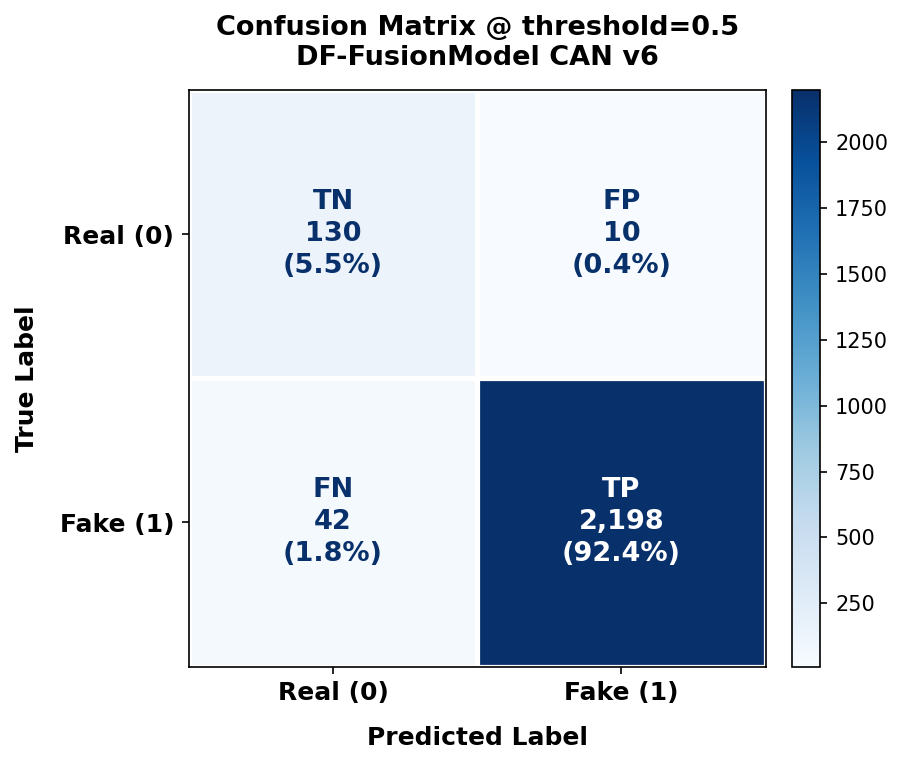

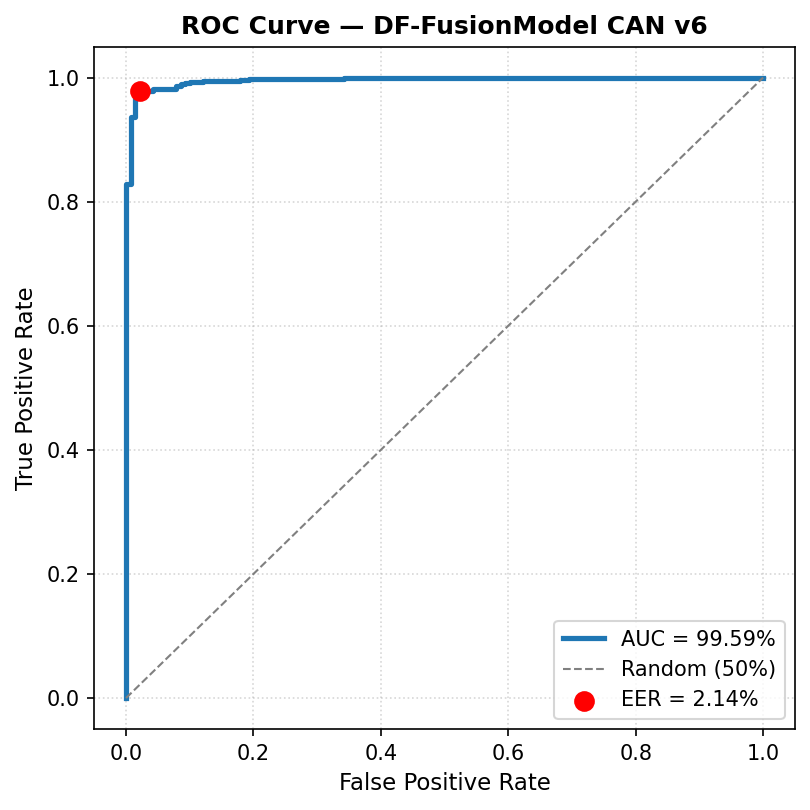

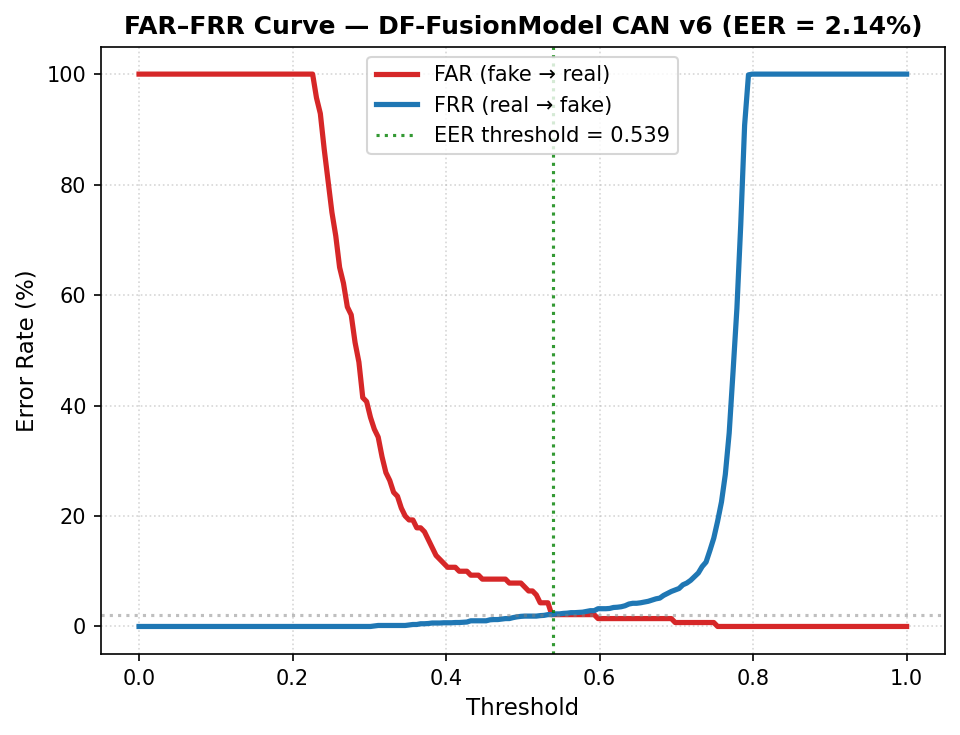


=== Breakdown theo phương pháp (real + từng loại fake) ===
        method  n_real  n_fake      auc      eer
NeuralTextures     140     560 0.992003 0.042857
     Face2Face     140     560 0.995612 0.023214
      FaceSwap     140     560 0.997054 0.021429
     Deepfakes     140     560 0.998980 0.014286

=== So sánh Ablation ===
         model       acc       auc       eer
  Spatial only    0.9657    0.9926    0.0286
rPPG only (v3)       TBD       TBD       TBD
 Fusion CAN v6  0.978151  0.995912  0.021429

✓ Đã lưu toàn bộ kết quả vào /kaggle/working/eval_fusion_can/


In [7]:
@torch.no_grad()
def evaluate_with_tta(model, loader, use_tta=True):
    model.eval()
    y_true, y_score = [], []
    for sp, app, mot, label, _ in tqdm(loader, desc="Evaluating Test Set"):
        sp, app, mot = sp.to(DEVICE), app.to(DEVICE), mot.to(DEVICE)
        logits_list = [model(sp, app, mot)]
        if use_tta:
            # TTA 1: flip horizontal
            logits_list.append(model(torch.flip(sp, [4]), torch.flip(app, [4]), torch.flip(mot, [4])))
            # TTA 2: nửa đầu clip
            T = app.shape[1]; half = max(T // 2, 1)
            logits_list.append(model(sp[:, :sp.shape[1]//2+1], app[:, :half], mot[:, :half]))
        prob = torch.stack([torch.sigmoid(l) for l in logits_list]).mean()
        y_score.append(prob.item()); y_true.append(label.item())
    return np.array(y_true), np.array(y_score)

ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
fusion_model.load_state_dict(ckpt["model_state"])
val_auc_log = ckpt.get('val_metrics', {}).get('auc', 'N/A')
print(f"Loaded best checkpoint: epoch={ckpt.get('epoch', '?')} stage={ckpt.get('stage', '?')} (val_auc={val_auc_log})")

y_true, y_score = evaluate_with_tta(fusion_model, test_loader, use_tta=True)
test_metrics = calc_metrics(y_true, y_score)

print(f"\n=== KẾT QUẢ TEST (FF++ C23) — {MODEL_NAME} + TTA ===")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%")
print(f"FAR @ EER           : {test_metrics['far_at_eer']*100:.2f}%  |  FRR @ EER: {test_metrics['frr_at_eer']*100:.2f}%")

cm = test_metrics["cm_at_0.5"]
print(f"\nConfusion Matrix @ 0.5:  TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

# ── 1. Confusion Matrix CHUẨN HÓA ──
plot_confusion_matrix_standard(cm, MODEL_NAME,
                                out_path=os.path.join(OUT_DIR, "confusion_matrix.png"))

# ── 2. ROC Curve ──
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=150)
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2.5, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]],
           color="red", zorder=5, s=80, label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate", fontsize=11); ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"ROC Curve — {MODEL_NAME}", fontsize=12, fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

# ── 3. FAR–FRR Curve ──
thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=150)
ax.plot(thr, fars * 100, lw=2.5, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2.5, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.8,
           label=f"EER threshold = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Threshold", fontsize=11); ax.set_ylabel("Error Rate (%)", fontsize=11)
ax.set_title(f"FAR–FRR Curve — {MODEL_NAME} (EER = {test_metrics['eer']*100:.2f}%)",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

# ── 4. Breakdown theo phương pháp fake ──
test_ordered = test_df.reset_index(drop=True)
assert len(test_ordered) == len(y_true), "Mismatch: test_df and y_true lengths differ!"
rows = []
real_mask = test_ordered["label"].values == 0
for method in sorted(test_ordered.loc[~real_mask, "method"].unique()):
    mm = test_ordered["method"].values == method
    sel = real_mask | mm
    m = calc_metrics(y_true[sel], y_score[sel])
    rows.append({"method": method, "n_real": int(real_mask.sum()),
                 "n_fake": int(mm.sum()), "auc": m["auc"], "eer": m["eer"]})
bd = pd.DataFrame(rows).sort_values("auc")
bd.to_csv(os.path.join(OUT_DIR, "auc_breakdown_by_method.csv"), index=False)
print("\n=== Breakdown theo phương pháp (real + từng loại fake) ===")
print(bd.to_string(index=False))

# ── 5. Bảng so sánh Ablation A ──
comp = pd.DataFrame([
    {"model": "Spatial only",     "acc": 0.9657, "auc": 0.9926, "eer": 0.0286},
    {"model": "rPPG only (v3)",   "acc": "TBD",  "auc": "TBD",  "eer": "TBD"},
    {"model": "Fusion CAN v6",    "acc": test_metrics["acc"], "auc": test_metrics["auc"], "eer": test_metrics["eer"]},
])
print("\n=== So sánh Ablation ===")
print(comp.to_string(index=False))
comp.to_csv(os.path.join(OUT_DIR, "ablation_table_A.csv"), index=False)

# ── 6. Lưu test_results_intra.csv ──
result_row = {
    "model": MODEL_NAME, "input_modality": "dual_spatial_rppg",
    "params_M": round(n_all / 1e6, 2),
    "best_epoch": f"{ckpt.get('epoch', '?')}|stage={ckpt.get('stage', '?')}",
    "acc_intra": test_metrics["acc"], "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
}
for _, r in bd.iterrows():
    result_row[f"auc_{r['method']}"] = r["auc"]
    result_row[f"eer_{r['method']}"] = r["eer"]
pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\n✓ Đã lưu toàn bộ kết quả vào {OUT_DIR}/")


## 8. Training Curves (đọc từ train_history.csv)

Đã tải 23 epochs từ /kaggle/input/datasets/thinhphan1506/trained-dffusionmodel-can-pth/fusion_model/train_history.csv


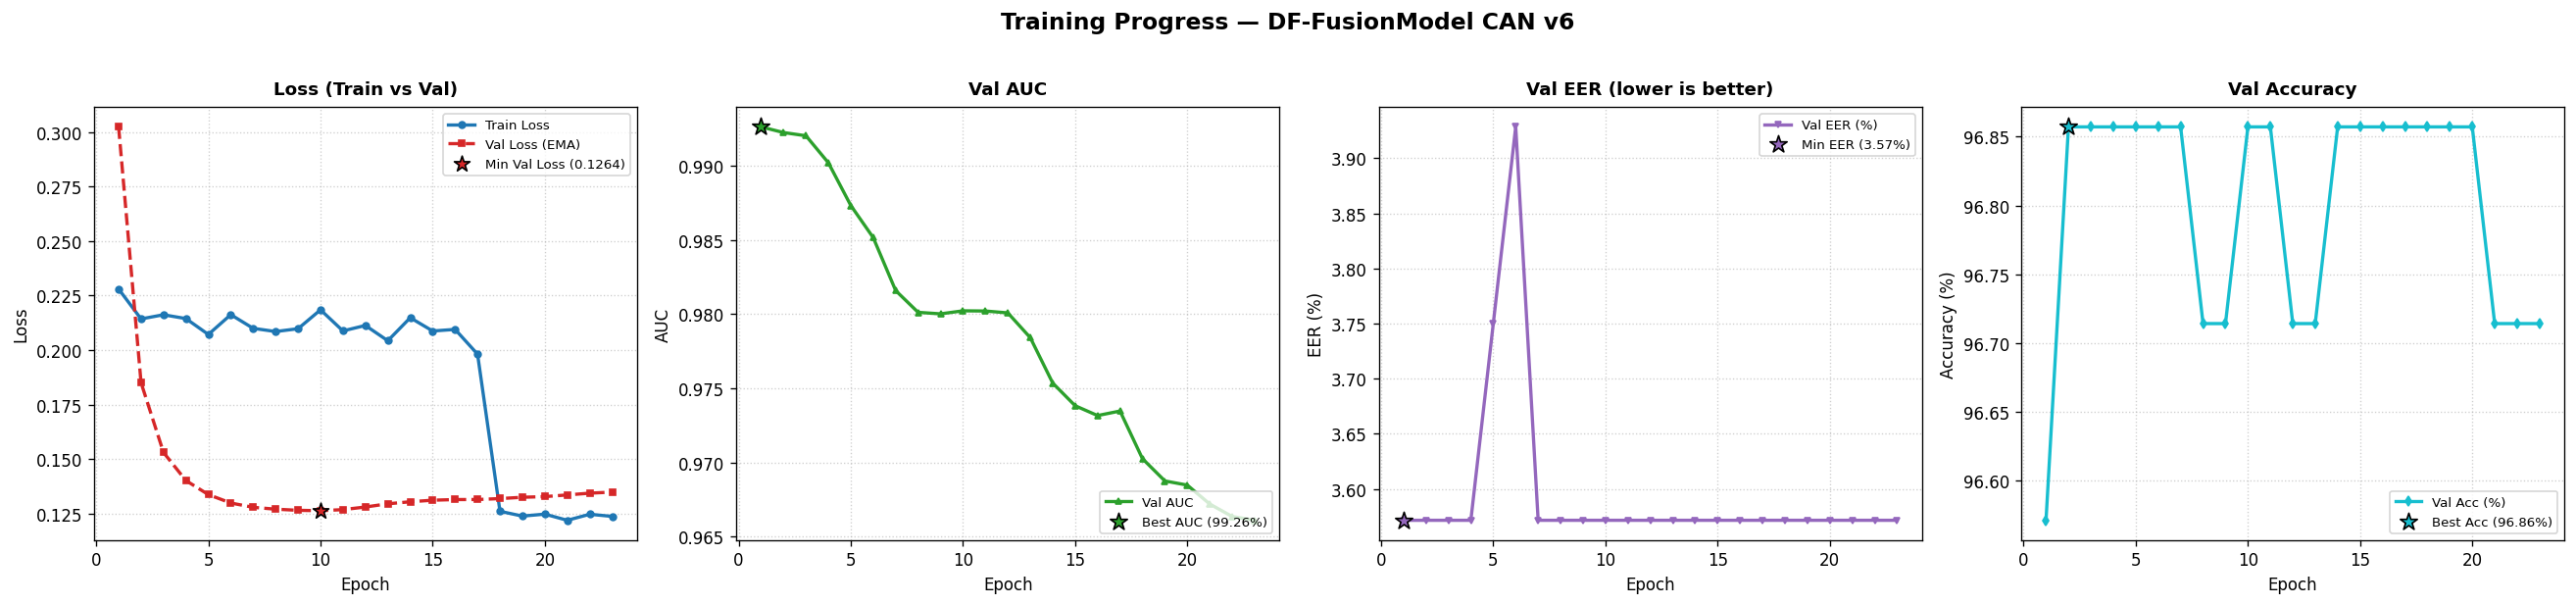

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Vẽ Training Curves CHUẨN HÓA (đọc từ train_history.csv kèm checkpoint)
# ══════════════════════════════════════════════════════════════════════════════
if os.path.exists(TRAIN_HISTORY_CSV):
    hist_df = pd.read_csv(TRAIN_HISTORY_CSV)
    print(f"Đã tải {len(hist_df)} epochs từ {TRAIN_HISTORY_CSV}")
    plot_training_curves_standard(hist_df, MODEL_NAME,
                                   out_path=os.path.join(OUT_DIR, "training_curves.png"))
else:
    print(f"⚠️ Không tìm thấy {TRAIN_HISTORY_CSV} — bỏ qua Training Curves.")
    print("   Thêm train_history.csv vào Kaggle Input cùng thư mục với checkpoint để hiển thị.")


## 9. ⚠️ Lưu kết quả

**Save Version → Save & Run All (Commit)** → **Output** → **New Dataset**:
- `confusion_matrix.png`, `roc_curve.png`, `far_frr_curve.png`, `training_curves.png`
- `auc_breakdown_by_method.csv`
